1wk data shape: (686517, 31)
0wk, CA forecaster_na: [893. 795. 546. 779. 781. 893. 720. 676. 809. 755. 616. 546. 515. 476.
 480. 480. 352. 454. 441. 409. 471.]
0wk, FL forecaster_na: [893. 795. 546. 779. 690. 893. 720. 648. 802. 748. 616. 546. 515. 501.
 487. 480. 352. 454. 441. 409. 469.]
0wk, GA forecaster_na: [893. 795. 546. 779. 795. 893. 720. 641. 816. 741. 616. 546. 515. 448.
 459. 480. 352. 454. 441. 409. 469.]
0wk, HI forecaster_na: [893. 795. 546. 779.   0. 893. 720. 697. 802. 755. 616. 546. 515. 501.
 473. 480. 352. 454. 441. 409. 469.]
0wk, US forecaster_na: [893. 795. 546. 779. 823. 893. 720. 676. 802. 734. 616. 546. 515. 501.
 494. 480. 352. 447. 441. 409. 441.]
2wk data shape: (687586, 31)
3wk data shape: (688337, 31)
4wk data shape: (687423, 31)


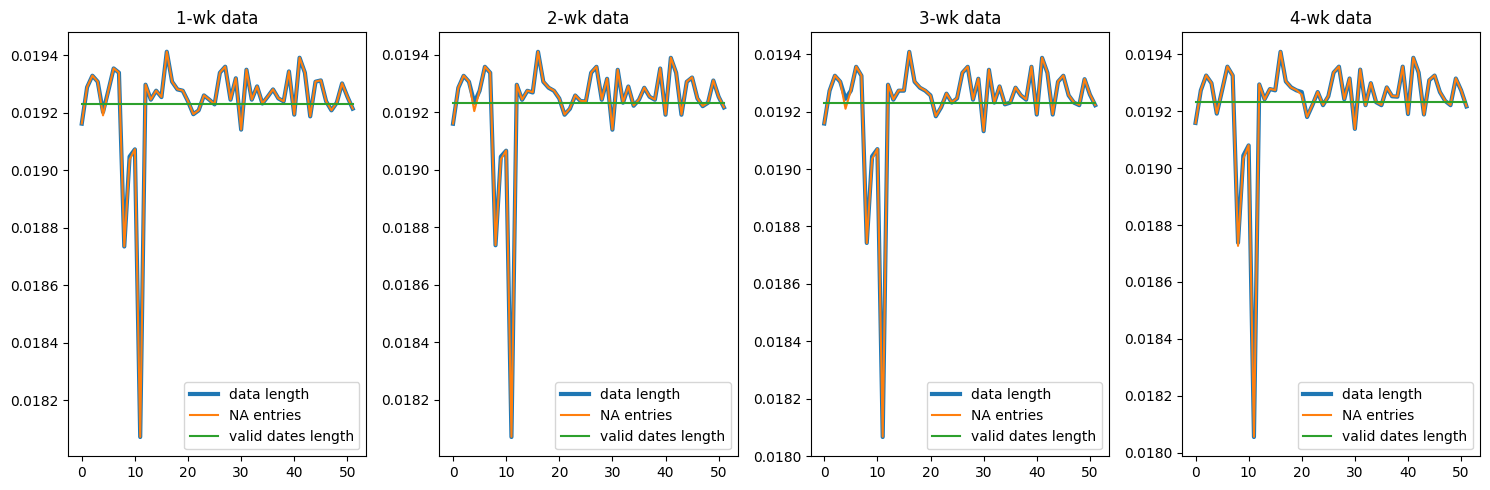

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import pickle

fig, ax = plt.subplots(1, 4, figsize=(15, 5))
forecaster_list = ['COVIDhub-4_week_ensemble', 'COVIDhub-trained_ensemble', 'JHUAPL-SLPHospEns', 'CU-select', 'GT-DeepCOVID', 'COVIDhub-baseline', 'Karlen-pypm',
 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-Gecko', 'MUNI-ARIMA', 'CMU-TimeSeries',
 'UMass-trends_ensemble', 'PSI-DICE', 'IHME-CurveFit', 'CUB_PopCouncil-SLSTM', 'BPagano-RtDriven',
 'LANL-GrowthRate', 'UVA-Ensemble'] # 'prolix-euclidean' only contain US
 
ens_model_list = ['COVIDhub-4_week_ensemble', 'COVIDhub-trained_ensemble', 'JHUAPL-SLPHospEns']

geo_list = ['al', 'ak', 'az', 'ar', 'ca', 'co', 'ct', 'de', 'dc', 'fl', 'ga', 'hi', 'id',
 'il', 'in', 'ia', 'ks', 'ky', 'la', 'me', 'md', 'ma', 'mi', 'mn', 'ms', 'mo',
 'mt', 'ne', 'nv', 'nh', 'nj', 'nm', 'ny', 'nc', 'nd', 'oh', 'ok', 'or', 'pa',
 'ri', 'sc', 'sd', 'tn', 'tx', 'ut', 'vt', 'va', 'wa', 'wv', 'wi', 'wy', 'us']

alpha_list = [0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 
0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]

covid_4wk_ens_start_date = '2020-12-29' 
covid_4wk_ens_end_date = '2023-06-09'
dates_list = pd.date_range(start=covid_4wk_ens_start_date, end=covid_4wk_ens_end_date).strftime('%Y-%m-%d')
dates_list_7 = dates_list[:(dates_list.size // 7) * 7]
dates_list_w = dates_list_7[::7]

df_list = []
for w in range(4):
    df_raw = pd.read_csv(f'../data/hospitalizations/hospitalizations_{w+1}wk.csv', index_col=0)
    df_raw = df_raw[(df_raw.target_end_date >= covid_4wk_ens_start_date) & 
                    (df_raw.target_end_date <= covid_4wk_ens_end_date) & 
                    df_raw.forecaster.isin(forecaster_list)]
    print(f'{w+1}wk data shape: {df_raw.shape}')
    
    data_len = np.zeros(len(geo_list))
    na_entries = np.zeros(len(geo_list))
    valid_dates_len = np.zeros(len(geo_list))

    for i, geo in enumerate(geo_list):
        df = df_raw[(df_raw.geo_value == geo)]
        valid_dates = sorted(df.target_end_date[df.actual.notna()].unique())
        prob_f_cols = [c for c in df.columns if c.startswith('forecast_0')]
        df_f = df.loc[:, prob_f_cols]
        data_len[i] = df_f.shape[0]
        na_entries[i] = df_f.notna().sum().sum()
        valid_dates_len[i] = len(valid_dates)

        if w==0 and geo in ['ca', 'fl', 'ga', 'hi', 'us']:
            forecaster_na = np.zeros(len(forecaster_list))
            for ixf, f_name in enumerate(forecaster_list):
                forecaster_na[ixf] = df.loc[df.forecaster == f_name, prob_f_cols].notna().sum().sum() / len(prob_f_cols)
            print(f'{w}wk, {geo.upper()} forecaster_na: {forecaster_na}')

        # print(f"{geo.upper()} {w+1}wk data shape: {df.shape}")
        # print(f"Number of non NA entries: {df_f.notna().sum().sum()}, Actual exists for {len(valid_dates)} dates")
        # print(f"First and last 3 dates with non-NA Y: {valid_dates[:3]} ... {valid_dates[-3:]}")
        # print(f"Target date range: {df.target_end_date.min()} to {df.target_end_date.max()}")
        # print(f"Range of ahead: {df.ahead.min()} to {df.ahead.max()}")
        
        df.drop(columns=['geo_value'], inplace=True)
        pickle.dump(df, open(f'../data/hospitalizations/{w+1}wk_states/{geo.upper()}.pkl', 'wb'))

    ax[w].plot(np.arange(len(geo_list)), data_len / np.sum(data_len), linewidth=3, label='data length')
    ax[w].plot(np.arange(len(geo_list)), na_entries / np.sum(na_entries), label='NA entries')
    ax[w].plot(np.arange(len(geo_list)), valid_dates_len / np.sum(valid_dates_len), label='valid dates length')
    ax[w].set_title(f'{w+1}-wk data')
    ax[w].legend()
fig.tight_layout()
plt.show()
# geo_list[34] = nd, valid dates length is shorter than others, starting from 200727 while others 0706 or 0713

### Build `df_data_dic`

In [2]:
from tqdm import tqdm

impute_na = False

def weekly_agg(series, dates_list_7):
    series = series[dates_list_7]
    group_index = np.arange(len(series)) // 7
    assert len(series) % 7 == 0
    series_w = series.groupby(group_index).sum(min_count=7)
    series_w.index = series.index[::7]
    return series_w

# Given df, take the latest forecast
def take_last_among_dup (df):
    assert all(col in df.columns for col in ['target_end_date', 'forecast_date'])
    return df.loc[df.groupby('target_end_date')['forecast_date'].idxmax()]

for geo in tqdm(geo_list):
    forecasts_dict = {}
    forecasts_dict_w = {}
    for w in range(1, 5):
        forecasts_dict[w] = {}
        forecasts_dict_w[w] = {}
        df_w_states = pickle.load(open(f'../data/hospitalizations/{w}wk_states/{geo.upper()}.pkl', 'rb'))

        if w == 1:
            g = df_w_states.groupby("target_end_date")["actual"]
            result = pd.DataFrame({
                "actual": g.first(),                       # candidate value
                "any_na": g.apply(lambda x: x.isna().any()),
                "n_unique_non_na": g.nunique(dropna=True)  # number of unique actual values
            })
            result["all_equal"] = result["n_unique_non_na"] == 1
            result["valid"] = (~result["any_na"]) & (result["all_equal"])
            if result.shape[0] != result["valid"].sum():
                print(f'{geo.upper()}     Start date: {result.index.min()}, End date: {result.index.max()}, # of dates in data: {result.shape[0]}')
                print(f'Not valid dates: {result.shape[0] - result["valid"].sum()} {result.index[result["valid"]]}')
            Y = result['actual'].sort_index()
            Y_w = weekly_agg(Y, dates_list_7)
            # check if index same to dates_list
            assert Y.index.equals(dates_list), f'{geo.upper()} Y index is not same to dates_list'

        for f_name in forecaster_list:
            forecasts_dict[w][f_name] = {}
            forecasts_dict_w[w][f_name] = {}
            df_here = df_w_states[df_w_states.forecaster == f_name]   
            date_start = pd.to_datetime(df_here.target_end_date.min())
            date_end = pd.to_datetime(df_here.target_end_date.max())
            date_range_length = (date_end - date_start).days + 1  # inclusive of endpoints
            
            # Duplicate check 
            ud, rc = np.unique(df_here.target_end_date, return_counts=True)
            if np.sum(rc > 1) >= 1:
                dup_dates = np.sort(ud[rc > 1])
                df_here = take_last_among_dup(df_here)
            
            for alpha in alpha_list:
                forecasts_dict[w][f_name][alpha] = (df_here[[f'forecast_{alpha}', 'target_end_date']]
                                                    .set_index('target_end_date')[f'forecast_{alpha}']
                                                    .reindex(dates_list)
                                                    )                                    
                
        if impute_na:
            for alpha in alpha_list:
                avg_of_others = (forecasts_dict[w][f_name][alpha] for f_name in forecaster_list if f_name not in ens_model_list)
                avg_of_others = pd.concat(avg_of_others, axis=1).median(axis=1, skipna=True)
                for f_name in forecaster_list:   
                    # if f_name != 'JHUAPL-SLPHospEns':
                    #     forecasts_dict[w][f_name][alpha] = forecasts_dict[w][f_name][alpha].fillna(avg_of_others)      
                    # else:
                    #     forecasts_dict[w][f_name][alpha] = forecasts_dict[w][f_name][alpha].fillna(forecasts_dict[w]['COVIDhub-4_week_ensemble'][alpha])
                    forecasts_dict[w][f_name][alpha] = forecasts_dict[w][f_name][alpha].fillna(avg_of_others)

        for f_name in forecaster_list:
            for alpha in alpha_list:
                forecasts_dict_w[w][f_name][alpha] = weekly_agg(forecasts_dict[w][f_name][alpha], dates_list_7)
            # if np.mean(avg_of_others < 1) > 1e-5:
            #     print(f'{geo} {w} {alpha} {np.mean(avg_of_others < 1)}')

    d = {}
    d['forecasts_dict'] = forecasts_dict
    d['alpha_list'] = alpha_list
    d['dates_list'] = dates_list
    d['forecaster_list'] = forecaster_list
    d['Y'] = Y
    if not impute_na:
        pickle.dump(d, open(f'../data/hospitalizations/preprocess_states/{geo.upper()}{"" if impute_na else "_raw"}.pkl', 'wb'))

    d['forecasts_dict'] = forecasts_dict_w
    d['dates_list'] = dates_list_w
    d['Y'] = Y_w
    if not impute_na:
        pickle.dump(d, open(f'../data/hospitalizations/preprocess_states_weekly/{geo.upper()}{"" if impute_na else "_raw"}.pkl', 'wb'))

100%|██████████| 52/52 [01:23<00:00,  1.61s/it]


In [3]:
# Sanity check
this_version = pickle.load(open('../data/hospitalizations/preprocess_states/US.pkl', 'rb'))
prev_version = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp.pkl', 'rb'))
print(this_version['forecasts_dict'][1]['COVIDhub-baseline'][0.01].iloc[-190:-180])
print(prev_version['forecasts_dict'][1]['COVIDhub-baseline'][0.01].iloc[-190:-180])

print('-'*100)
this_version = pickle.load(open('../data/hospitalizations/preprocess_states_weekly/US.pkl', 'rb'))
prev_version = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp_weekly.pkl', 'rb'))
print(this_version['forecasts_dict'][1]['COVIDhub-baseline'][0.01].iloc[-20:-10])
print(prev_version['forecasts_dict'][1]['COVIDhub-baseline'][0.01].iloc[-20:-10])


2022-12-02       0.000000
2022-12-03       0.000000
2022-12-04       0.000000
2022-12-05       0.000000
2022-12-06    1542.513963
2022-12-07    1217.928992
2022-12-08     924.388654
2022-12-09     627.517225
2022-12-10     362.961835
2022-12-11      46.056731
Name: forecast_0.01, dtype: float64
2022-12-03       0.000000
2022-12-04       0.000000
2022-12-05       0.000000
2022-12-06    1542.513963
2022-12-07    1217.928992
2022-12-08     924.388654
2022-12-09     627.517225
2022-12-10     362.961835
2022-12-11      46.056731
2022-12-12       0.000000
Name: forecast_0.01, dtype: float64
----------------------------------------------------------------------------------------------------
2023-01-17    5620.746969
2023-01-24    2851.021218
2023-01-31     817.369197
2023-02-07     467.390358
2023-02-14     644.366842
2023-02-21     425.400301
2023-02-28      93.206468
2023-03-07       0.000000
2023-03-14       0.000000
2023-03-21       0.000000
Name: forecast_0.01, dtype: float64
2023-01-17 